# project_01_validation_harness — all notebooks (00→05) in one

This is a **convenience copy** that concatenates the six standalone notebooks in order so you can run the whole project top-to-bottom in a single Colab session. The individual notebooks (`00_setup.ipynb` … `05_validation_plan.ipynb`) remain in this folder and are the canonical deliverables. Sections are separated by dividers; each section keeps its own setup/`import` cells (re-running them is harmless). All synthetic numbers are still labeled `EXAMPLE_DATA`.

---

## ▶︎ Section 1 / 6 — `00_setup.ipynb`

---

# 00 · Environment Setup — De Novo Protein Design Capstone

This is the **shared setup notebook** every project starts from. Run it top to bottom
*once per Colab session*. It:

1. detects your GPU and warns if you're on a weak/absent one,
2. installs a light, pinned core toolset (Biopython, py3Dmol, foldseek-less utilities),
3. optionally installs heavier tools (ColabFold, ESMFold) on demand,
4. prints exact versions for your `LOG.md` (reproducibility is graded).

> **Compute reality.** A free Colab **T4** runs ColabFold, ESMFold, ProteinMPNN, and small
> RFdiffusion jobs. **BindCraft / RFantibody / large RFdiffusion** want an **A100** (Colab Pro+
> or a cluster). Each project's `MANUAL.md` states its tier. Don't fight a T4 to do an A100 job —
> plan your batch sizes around it.

## 1 · GPU & environment check

In [1]:
import subprocess, sys, platform, textwrap

def sh(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()

print("Python :", sys.version.split()[0])
print("Platform:", platform.platform())

gpu = sh("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null")
if gpu:
    print("GPU    :", gpu)
    name = gpu.lower()
    if "t4" in name:
        print(textwrap.fill(
            "NOTE: T4 detected. Good for ColabFold/ESMFold/ProteinMPNN/small RFdiffusion. "
            "For BindCraft/RFantibody/large diffusion, switch to A100 (Colab Pro+) or a cluster.", 88))
    elif any(x in name for x in ("a100", "l4", "v100")):
        print("NOTE: capable GPU — heavier tools (BindCraft/RFantibody) are feasible.")
else:
    print("GPU    : NONE FOUND")
    print(textwrap.fill(
        "WARNING: No GPU. Go to Runtime → Change runtime type → Hardware accelerator → GPU. "
        "Structure prediction on CPU is impractically slow.", 88))

Python : 3.11.15
Platform: Linux-6.18.5-x86_64-with-glibc2.39
GPU    : NONE FOUND
Structure prediction on CPU is impractically slow.


## 2 · Pinned core install (fast, T4-friendly)

These are light and used across every project. Pins are conservative; bump them in your repo if needed and **log it**.

In [2]:
# Core utilities used in every project. Quiet + pinned.
%pip -q install biopython==1.84 py3Dmol==2.4.0 numpy pandas matplotlib seaborn tqdm requests 2>/dev/null
print("Core install done.")

Note: you may need to restart the kernel to use updated packages.
Core install done.


In [3]:
# Version stamp — copy this block's output into your LOG.md for reproducibility.
import importlib, datetime
mods = ["Bio", "py3Dmol", "numpy", "pandas", "matplotlib", "seaborn", "tqdm", "requests"]
print("# Environment stamp", datetime.datetime.utcnow().isoformat(timespec="seconds"), "UTC")
for m in mods:
    try:
        v = importlib.import_module(m).__version__
    except Exception:
        v = "n/a"
    print(f"{m:14s} {v}")

# Environment stamp 2026-06-24T03:14:15 UTC
Bio            1.84
py3Dmol        2.4.0


numpy          2.4.6


pandas         3.0.3
matplotlib     3.11.0


seaborn        0.13.2
tqdm           4.68.3
requests       2.33.1


## 3 · Heavy tools — install *on demand*

Don't install these unless your project needs them this session (they're slow to set up).
Each is wrapped in a function so you only pay the cost when you call it.

In [4]:
def install_colabfold():
    """ColabFold (AF2). ~3–5 min on first install. T4 OK."""
    import subprocess
    subprocess.run("pip -q install 'colabfold[alphafold-minus-jax]'", shell=True)
    # On Colab, the standard route is the localcolabfold installer or the ColabFold notebook;
    # here we expose the pip route. If it fails, fall back to the official ColabFold notebook
    # and import your sequences. Log whichever path you used.
    print("ColabFold install attempted. Verify with: from colabfold.batch import run")

def install_esmfold():
    """ESMFold via HuggingFace transformers. T4 OK for <~400 aa."""
    import subprocess
    subprocess.run("pip -q install 'transformers>=4.40' accelerate", shell=True)
    print("ESMFold deps installed. Load with transformers EsmForProteinFolding.")

print("Helpers ready: install_colabfold(), install_esmfold().")

Helpers ready: install_colabfold(), install_esmfold().


## 4 · Reproducibility helpers

Call `set_seeds()` at the top of every run, and use `log()` to append to your `LOG.md`.

In [5]:
import os, random
import numpy as np

def set_seeds(seed: int = 0):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
    print(f"seeds set to {seed}")

def log(msg: str, path: str = "LOG.md"):
    import datetime
    stamp = datetime.datetime.utcnow().isoformat(timespec="seconds")
    with open(path, "a") as fh:
        fh.write(f"- {stamp}Z · {msg}\n")
    print("logged:", msg)

set_seeds(0)
log("Ran 00_setup; environment stamped.")

seeds set to 0
logged: Ran 00_setup; environment stamped.


## 5 · (Optional) Mount Google Drive for persistence

Colab sessions are ephemeral. Mount Drive to keep your `results/` and design pools between sessions.

In [6]:
# from google.colab import drive
# drive.mount("/content/drive")
# WORKDIR = "/content/drive/MyDrive/denovo_capstone/project_XX"
# import os; os.makedirs(WORKDIR, exist_ok=True); os.chdir(WORKDIR)
print("Uncomment to mount Drive and set your working directory.")

Uncomment to mount Drive and set your working directory.


---
**Next:** open `01_define_and_explore.ipynb`. Keep this session alive — re-running `00_setup`
each new session is normal. Record every version and seed in `LOG.md`.

---

## ▶︎ Section 2 / 6 — `01_define_and_explore.ipynb`

---

# 01 · Define & Explore — confidence metrics + the prediction wrapper

**Standard slot:** *define & explore.* **For Project 01 this means:** pin down what each confidence
metric means, then stand up the unified `predict()` wrapper and run it on **one** sequence as your
"hello-world" (D0).

Run `00_setup.ipynb` first in this session.

## The metrics, precisely

| Metric | Range | Means | Does **not** mean |
|--------|-------|-------|-------------------|
| pLDDT | 0–100 | per-residue *local* confidence | thermostability / ΔG |
| PAE | Å | expected error in residue-pair *relative* position | per-residue quality |
| pTM / ipTM | 0–1 | global / interface fold confidence | correctness guarantee |
| scRMSD | Å | designed-vs-predicted Cα-RMSD (self-consistency) | binding/function |
| TM-score | 0–1 | similarity to nearest known fold (<0.5 ≈ novel) | a pass/fail of correctness |

Write your own one-paragraph definitions in `D0` — including the "does not mean" column, which is
where most published mistakes live.

## Setup paths

In [7]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_01_validation_harness/notebooks


## The unified prediction wrapper

`scripts/predict.py` exposes `predict(sequence, tool)` → a uniform record. The real backends
(ESMFold/AF2/Boltz) need GPU + heavy installs (see `00_setup` helpers); a **mock** backend lets you
build and test the plumbing first. **Never report mock numbers as real.**

In [8]:
from predict import predict, predict_all, Prediction

UBIQUITIN = ("MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG")

# Start with the mock backend to confirm the plumbing, THEN switch tool="esmfold".
p = predict(UBIQUITIN, tool="mock")
print(p.as_row())

{'tool': 'mock', 'sequence': 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG', 'pdb_path': None, 'plddt': 56.0, 'pae': 11.0, 'ptm': 0.56, 'runtime_s': 0.0, 'ok': True, 'error': 'SYNTHETIC — mock backend, not a real prediction'}


### Switch to a real predictor

Once `00_setup`'s `install_esmfold()` has run in this session, change `tool="mock"` to
`tool="esmfold"` and rerun. ESMFold is the fastest real backend (no MSA), so it's the right
hello-world. Record runtime + version in `LOG.md`.

In [9]:
# Uncomment after install_esmfold() in 00_setup:
# from predict import predict
# p = predict(UBIQUITIN, tool="esmfold")
# print(p.as_row())
# assert p.ok, p.error
print("Ready — flip to tool='esmfold' when ESMFold is installed this session.")

Ready — flip to tool='esmfold' when ESMFold is installed this session.


## Visualize a structure (py3Dmol)
Use this to eyeball any predicted PDB once you have one.

In [10]:
import py3Dmol

def show_pdb(pdb_path_or_str, is_path=True):
    data = open(pdb_path_or_str).read() if is_path else pdb_path_or_str
    view = py3Dmol.view(width=500, height=400)
    view.addModel(data, "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    view.zoomTo()
    return view.show()

# Example (after you have a real prediction):
# show_pdb(p.pdb_path)
print("show_pdb(pdb_path) ready.")

show_pdb(pdb_path) ready.


## D0 checklist
- [ ] One-paragraph definition of each metric **with** its "does not mean" note.
- [ ] One reproduced real prediction (ESMFold) on a natural protein, with its pLDDT printed.
- [ ] `LOG.md` entry: tool version, GPU, runtime, seed.

**Next:** `02_generate.ipynb` — curate the labeled dataset and predict it all.

---

## ▶︎ Section 3 / 6 — `02_generate.ipynb`

---

# 02 · Campaign — curate the labeled dataset + predict everything

**Standard slot:** *design campaign.* **For Project 01 this means:** there is nothing to *generate* —
your "campaign" is assembling a trustworthy **labeled benchmark** and predicting every item with all
three tools (D2). The labels are the hard part; start dataset curation in Week 1.

## Setup paths

In [11]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_01_validation_harness/notebooks


## 1 · The dataset schema

Create `data/dataset.csv` with one row per labeled item. Provenance columns are **graded** — every
item must say where its label came from. See `data/README.md` for sources and the licensing policy.

In [12]:
import pandas as pd, os

SCHEMA = ["id", "sequence", "design_type", "source_doi", "source_table",
          "license", "outcome", "outcome_detail", "notes"]

# A tiny seed so the notebook runs end-to-end before your real curation is done.
# REPLACE with your ≥40 designs + ≥10 natural refs. outcome ∈ {success, fail}.
seed_rows = [
    dict(id="nat_ubiquitin", sequence=("MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"),
         design_type="monomer", source_doi="PDB:1UBQ", source_table="RCSB",
         license="public-domain", outcome="success", outcome_detail="natural, folds", notes="positive ref"),
    dict(id="nat_trpcage", sequence="NLYIQWLKDGGPSSGRPPPS", design_type="monomer",
         source_doi="PDB:1L2Y", source_table="RCSB", license="public-domain",
         outcome="success", outcome_detail="natural mini-protein", notes="positive ref"),
]
os.makedirs("../data", exist_ok=True)
path = "../data/dataset.csv"
if not os.path.exists(path):
    pd.DataFrame(seed_rows, columns=SCHEMA).to_csv(path, index=False)
    print("seeded", path, "— REPLACE with your curated set (>=40 designs + >=10 refs).")
df = pd.read_csv(path)
print(df.shape); df.head()

seeded ../data/dataset.csv — REPLACE with your curated set (>=40 designs + >=10 refs).
(2, 9)


,id,sequence,design_type,source_doi,source_table,license,outcome,outcome_detail,notes
0,nat_ubiquitin,MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFA...,monomer,PDB:1UBQ,RCSB,public-domain,success,"natural, folds",positive ref
1,nat_trpcage,NLYIQWLKDGGPSSGRPPPS,monomer,PDB:1L2Y,RCSB,public-domain,success,natural mini-protein,positive ref


## 2 · Predict every item with every tool

Embarrassingly parallel but compute-bound on a T4: **triage with ESMFold** (seconds), reserve AF2
full-MSA for the subset that matters, batch overnight. Below uses the `mock` backend so the loop
runs anywhere; switch `TOOLS` to the real ones on Colab.

In [13]:
from predict import predict
import pandas as pd, time

TOOLS = ["mock"]   # → ["esmfold", "af2", "boltz"] on Colab once installed
rows = []
for _, r in df.iterrows():
    for tool in TOOLS:
        p = predict(r["sequence"], tool=tool)
        rows.append(dict(id=r["id"], design_type=r["design_type"], tool=p.tool,
                         plddt=p.plddt, pae=p.pae, ptm=p.ptm,
                         runtime_s=p.runtime_s, ok=p.ok, error=p.error,
                         outcome=r["outcome"]))
pred = pd.DataFrame(rows)
pred.to_csv("results/predictions.csv", index=False)
print("wrote results/predictions.csv", pred.shape)
pred.head()

wrote results/predictions.csv (2, 10)


,id,design_type,tool,plddt,pae,ptm,runtime_s,ok,error,outcome
0,nat_ubiquitin,monomer,mock,56.0,11.0,0.56,0.0,True,"SYNTHETIC — mock backend, not a real prediction",success
1,nat_trpcage,monomer,mock,90.0,5.0,0.90,0.0,True,"SYNTHETIC — mock backend, not a real prediction",success


## 3 · MSA-depth ablation (AF2) `[extension]`

On a subset, run AF2 with full MSA vs single-sequence and compare pLDDT/scRMSD. This shows how much
of AF2's confidence is "borrowed" from homologs — directly relevant to how it behaves on *de novo*
sequences with no MSA. Record both settings per item.

In [14]:
# Pseudocode for the ablation (fill in once ColabFold is wired in predict.py):
# for seq in subset:
#     full = predict(seq, tool="af2")              # default mmseqs2 MSA
#     single = predict(seq, tool="af2", msa_mode="single_sequence")
#     record (seq, full.plddt, single.plddt, delta)
print("Ablation scaffold — implement with the real AF2 backend.")

Ablation scaffold — implement with the real AF2 backend.


## D2 checklist
- [ ] `data/dataset.csv`: ≥40 designs + ≥10 natural refs, full provenance per row.
- [ ] `results/predictions.csv`: every item × tool with parsed metrics.
- [ ] Prediction log (tool versions, params, seeds, runtimes) in `LOG.md`.
- [ ] 3–4 page interim report.

**Next:** `03_filter_and_rank.ipynb` — run the shared filter on your predictions.

---

## ▶︎ Section 4 / 6 — `03_filter_and_rank.ipynb`

---

# 03 · Filter & Rank — run the shared multi-layer filter

**Standard slot:** *filter & rank* via `shared/filtering_pipeline.py` — the same module all 25
projects use. **For Project 01** you're both a *user* (run it on your predictions) and its *author*
(P4 hardens its cutoffs from your calibration).

Run `00`–`02` first so `results/predictions.csv` exists.

## Setup paths

In [15]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_01_validation_harness/notebooks


## Load the shared filtering pipeline
This is the cohort's shared module — improvements here are pull-requested back for everyone.

In [16]:
import filtering_pipeline as fp
import pandas as pd

print("DEFAULT_CUTOFFS:")
for k, v in fp.DEFAULT_CUTOFFS.items():
    print(" ", k, v)

DEFAULT_CUTOFFS:
  monomer {'scrmsd': 2.0, 'plddt': 85, 'pae': None}
  binder {'scrmsd': 2.5, 'plddt': 80, 'pae': 10, 'rosetta_dG': -30, 'sc': 0.6}
  enzyme {'scrmsd': 2.0, 'plddt': 85, 'plddt_cat': 90, 'cat_geom': 0.5}
  antibody {'scrmsd': 3.0, 'plddt': 70, 'pae': 12}
  oligomer {'scrmsd': 2.5, 'plddt': 80, 'pae': 10}


## Build `Design` objects from your predictions

The filter operates on `fp.Design` records. Map your per-tool predictions onto its fields. For a
pure-confidence benchmark you may not have `designed_pdb`/`predicted_pdb` paths for every item — set
the metrics you do have; `self_consistency()` uses provided `scrmsd` if present.

In [17]:
pred = pd.read_csv("results/predictions.csv")

# Use AF2 if available, else fall back to whatever tool you ran (mock for the dry run).
def pick_tool(g):
    for t in ("af2", "esmfold", "boltz", "mock"):
        if t in set(g["tool"]):
            return g[g["tool"] == t].iloc[0]
    return g.iloc[0]

designs = []
for _id, g in pred.groupby("id"):
    row = pick_tool(g)
    designs.append(fp.Design(
        design_id=str(_id),
        sequence="",                       # not needed for the confidence layers
        design_type="monomer",
        plddt=row.get("plddt"),
        pae_interaction=row.get("pae"),
        # scrmsd=...,                       # fill once you compute design-vs-predicted Cα-RMSD
        extra={"outcome": row.get("outcome")},
    ))
print(len(designs), "Design objects built")

2 Design objects built


## Run the pipeline

`run_pipeline()` applies the layers in order and returns a ranked DataFrame. With only pLDDT/PAE
present (no scRMSD yet), expect the self-consistency layer to be lenient — that's fine for the dry
run; the point of Project 01 is to *calibrate* these cutoffs in notebook 04.

Total designs: 2
  L1 survivors: 0  (0.0%)
  L2 survivors: 0  (0.0%)
  L3 survivors: 0  (0.0%)


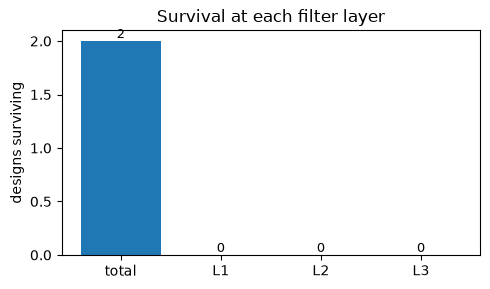

,design_id,sequence,design_type,designed_pdb,predicted_pdb,plddt,plddt_catalytic,pae_interaction,scrmsd,scrmsd_orthogonal,tm_to_pdb,solubility,rosetta_dG,shape_complementarity,md_rmsd,catalytic_geom_rmsd,extra,layers_passed,score,notes
0,nat_trpcage,,monomer,None,None,90.0,None,5.0,None,None,None,None,None,None,None,None,{'outcome': 'success'},0,1.4833,[failed L1 self-consistency]
1,nat_ubiquitin,,monomer,None,None,56.0,None,11.0,None,None,None,None,None,None,None,None,{'outcome': 'success'},0,0.6433,[failed L1 self-consistency]


In [18]:
df_ranked = fp.run_pipeline(designs, design_type="monomer")
df_ranked.to_csv("results/ranked.csv", index=False)
fp.report(df_ranked, top_n=10, save_prefix="results/proj01")
df_ranked.head(10)

## Survival-at-each-layer (honest accounting)

Report how many designs pass each layer. For Project 01 the more important table comes next
(metric vs *known outcome*), but the survival view is the standard cohort artifact.

In [19]:
import pandas as pd
if "layers_passed" in df_ranked:
    print(df_ranked["layers_passed"].value_counts().sort_index())

layers_passed
0    2
Name: count, dtype: int64


## D3 (part 1) checklist
- [ ] `results/ranked.csv` produced by the **shared** module (not a one-off script).
- [ ] Survival-at-each-layer reported.
- [ ] Any mapping assumptions (which tool, which fields) written down.

**Next:** `04_validate.ipynb` — the calibration study (ROC/PR, composite, agreement).

---

## ▶︎ Section 5 / 6 — `04_validate.ipynb`

---

# 04 · Validate — calibration study (ROC/PR, composite, agreement)

**Standard slot:** *validate (in silico).* **For Project 01 this is the core science:** which metric
actually predicts the *known* experimental outcome, at what cutoff, and how do the three predictors
agree? (D3.)

Needs `results/predictions.csv` with a real `outcome` column (success/fail).

## Setup paths

In [20]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_01_validation_harness/notebooks


## 1 · ROC / PR per metric

Sweep each metric's threshold and measure separation against the true outcome. Report AUC. PR is
more informative than ROC when successes are rare. **Note metric direction:** higher pLDDT = better,
but lower PAE and lower scRMSD = better, so flip their sign before scoring.

In [21]:
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

pred = pd.read_csv("results/predictions.csv")
# Collapse to one row per design using a chosen tool (prefer AF2).
order = {"af2":0,"esmfold":1,"boltz":2,"mock":3}
pred["pri"] = pred["tool"].map(order).fillna(9)
one = pred.sort_values("pri").groupby("id", as_index=False).first()
y = (one["outcome"].astype(str).str.lower() == "success").astype(int).values

# Higher-is-better score per metric (flip PAE).
metrics = {}
if one["plddt"].notna().any(): metrics["pLDDT"] = one["plddt"].values
if one["pae"].notna().any():   metrics["-PAE"]  = -one["pae"].values
if one["ptm"].notna().any():   metrics["pTM"]   = one["ptm"].values

def safe_auc(yv, s):
    m = ~pd.isna(s)
    return roc_auc_score(yv[m], np.asarray(s)[m]) if len(set(yv[m])) > 1 else float("nan")

print("AUC by single metric:")
for name, s in metrics.items():
    print(f"  {name:6s} ROC-AUC={safe_auc(y, s):.3f}  PR-AUC={average_precision_score(y, np.nan_to_num(s)):.3f}")

AUC by single metric:
  pLDDT  ROC-AUC=nan  PR-AUC=1.000
  -PAE   ROC-AUC=nan  PR-AUC=1.000
  pTM    ROC-AUC=nan  PR-AUC=1.000


/tmp/ipykernel_7023/843232645.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.title("Metric ROC vs experimental outcome"); plt.legend()


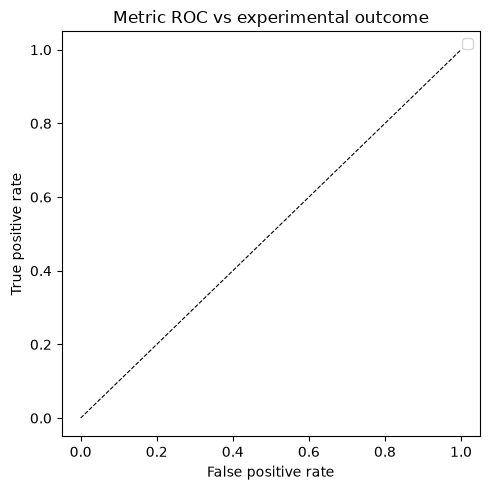

In [22]:
# ROC curves (only meaningful with a real labeled dataset; trivial on the 2-row seed).
plt.figure(figsize=(5,5))
for name, s in metrics.items():
    m = ~pd.isna(s)
    if len(set(y[m])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y[m], np.asarray(s)[m])
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0,1],[0,1],"k--",lw=0.8)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Metric ROC vs experimental outcome"); plt.legend()
plt.tight_layout(); plt.savefig("results/roc_metrics.png", dpi=150); plt.show()

## 2 · Composite predictor `[extension]`

Fit a simple logistic regression on the standardized metrics and compare its cross-validated AUC to
the best single metric. Keep it to a few features and **report N** — with a small dataset this
overfits easily; use cross-validation and report a confidence interval (bootstrap).

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

feat_cols = [c for c in ["plddt","pae","ptm"] if one[c].notna().all()]
if len(feat_cols) >= 2 and len(set(y)) > 1 and len(y) >= 10:
    X = one[feat_cols].values
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    auc = cross_val_score(clf, X, y, cv=min(5, sum(y), sum(1-y)), scoring="roc_auc")
    print(f"composite CV ROC-AUC = {auc.mean():.3f} ± {auc.std():.3f}  (features={feat_cols}, N={len(y)})")
else:
    print("Need a real labeled dataset (N>=10, both classes, >=2 complete features) for the composite model.")

Need a real labeled dataset (N>=10, both classes, >=2 complete features) for the composite model.


## 3 · AF2 / ESMFold / Boltz agreement

Correlate the predictors' pLDDT (and scRMSD once computed). Disagreement maps the harness's blind
spots — often novel folds or MSA-poor sequences. Flag and discuss them.

In [24]:
wide = pred.pivot_table(index="id", columns="tool", values="plddt")
if wide.shape[1] >= 2:
    print("pLDDT correlation across tools:")
    print(wide.corr().round(2))
    import matplotlib.pyplot as plt
    pd.plotting.scatter_matrix(wide, figsize=(6,6)); plt.suptitle("Cross-tool pLDDT"); plt.tight_layout()
    plt.savefig("results/agreement.png", dpi=150); plt.show()
else:
    print("Run >=2 tools to assess agreement.")

Run >=2 tools to assess agreement.


## D3 (part 2) checklist
- [ ] ROC/PR + AUC for every metric, with N and (ideally) bootstrap CIs.
- [ ] Best single metric identified; composite model compared honestly.
- [ ] Cross-tool agreement reported; disagreement cases flagged.
- [ ] Failure-mode table: where does the best predictor get it wrong, and on what kind of design?

**Next:** `05_validation_plan.ipynb` — turn this into the cohort SOP.

---

## ▶︎ Section 6 / 6 — `05_validation_plan.ipynb`

---

# 05 · Validation SOP — calibrate the shared cutoffs + write the cohort guide

**Standard slot:** *validation plan.* **For Project 01 this means:** convert your calibration (nb 04)
into an evidence-backed **SOP card** and harden `shared/filtering_pipeline.py`'s `DEFAULT_CUTOFFS`
so Projects 02–25 inherit your work (D4).

## Setup paths

In [25]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_01_validation_harness/notebooks


## 1 · Draft the SOP card

Fill each cutoff from your results, with the **evidence** behind it (AUC, N). This card is the
deliverable other students will actually read. Save it to `data/SOP.md` (or the repo root).

In [26]:
sop = """# Validation SOP (Project 01 — calibrated by <your name>, <date>)

Recommended in-silico cutoffs for de novo design triage, by design type.
Each row cites the evidence (ROC-AUC and N) from this project's calibration study.

| Design type | Metric | Cutoff | Evidence (AUC, N) | Notes |
|-------------|--------|--------|-------------------|-------|
| monomer | scRMSD | < ?.? A | AUC=?.??, N=? | self-consistency |
| monomer | pLDDT | > ?? | AUC=?.??, N=? | local confidence, NOT stability |
| binder  | pae_interaction | < ?? A | AUC=?.??, N=? | interface confidence |
| enzyme  | catalytic_geom_rmsd | < ?.? A | (if labels allow) | active-site geometry |

## Required controls for EVERY downstream project
- Positive control: a known-good design or natural protein.
- Negative control: scrambled-interface (binders) or catalytic dead-mutant (enzymes).
- Unrelated-protein control.

## Known limitations (state these honestly)
- No single metric perfectly separates outcomes; use the composite where N allows.
- Predictors can be overconfident on novel folds / MSA-poor sequences (see agreement analysis).
- Cutoffs are calibrated on <dataset description>; revisit if your design type differs.
"""
open("../data/SOP.md", "w").write(sop)
print("wrote ../data/SOP.md — fill in the ? values from notebook 04.")

wrote ../data/SOP.md — fill in the ? values from notebook 04.


## 2 · Harden the shared cutoffs

Edit `shared/filtering_pipeline.py`'s `DEFAULT_CUTOFFS` to your calibrated values **via pull
request**, so the change is reviewed and versioned for the whole cohort. Below shows the current
values and a template for proposing new ones — do **not** silently overwrite the shared file from a
notebook.

In [27]:
import filtering_pipeline as fp
print("CURRENT shared DEFAULT_CUTOFFS:")
for k, v in fp.DEFAULT_CUTOFFS.items():
    print(" ", k, v)

proposed = {
    # "monomer": {"max_scrmsd": ?.?, "min_plddt": ??, ...},   # fill from your calibration
}
print("\nProposed (put these in your PR description with the AUC/N evidence):")
print(proposed)

CURRENT shared DEFAULT_CUTOFFS:
  monomer {'scrmsd': 2.0, 'plddt': 85, 'pae': None}
  binder {'scrmsd': 2.5, 'plddt': 80, 'pae': 10, 'rosetta_dG': -30, 'sc': 0.6}
  enzyme {'scrmsd': 2.0, 'plddt': 85, 'plddt_cat': 90, 'cat_geom': 0.5}
  antibody {'scrmsd': 3.0, 'plddt': 70, 'pae': 12}
  oligomer {'scrmsd': 2.5, 'plddt': 80, 'pae': 10}

Proposed (put these in your PR description with the AUC/N evidence):
{}


## 3 · (Stretch) Boltz-2 affinity vs measured K_D `[stretch]`

If any dataset items carry a measured K_D, compare Boltz-2's predicted affinity against it
(scatter + Spearman ρ) and report the correlation with caveats. This tells downstream binder
projects how far to trust predicted affinity.

In [28]:
# Scaffold: join measured KD (from dataset.csv notes) with Boltz-2 predicted affinity,
# then report Spearman correlation. Implement once the Boltz backend is wired in predict.py.
print("Stretch task — implement with the real Boltz-2 affinity output.")

Stretch task — implement with the real Boltz-2 affinity output.


## D4 / D5 checklist
- [ ] `data/SOP.md` completed with calibrated cutoffs + evidence per row + required controls.
- [ ] Pull request hardening `shared/filtering_pipeline.py` `DEFAULT_CUTOFFS` (reviewed, not silent).
- [ ] Cohort usage guide ("how to use this harness") written.
- [ ] Thesis chapter + 15-min talk + `v1.0` tagged release (the cohort's official harness).

You're done — and Projects 02–25 now stand on your calibration.